# Simulation (Supplementary Figure 1,2)

This notebook reproduces the `scripts/1.simulation/simulation.py` workflow panel by panel for **Supplementary Figure 1** and **Supplementary Figure 2**.

It is intended for interactive inspection: run one section at a time, check the plots, and only rerun the heavier simulation cells when needed.

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import pandas as pd
import torch as pt

warnings.filterwarnings('ignore', message='torch.set_default_tensor_type')

HERE = Path.cwd().resolve()
candidates = [HERE, *HERE.parents]
REPO_ROOT = next((p for p in candidates if (p / 'scripts' / '1.simulation' / 'simulation.py').exists()), None)
if REPO_ROOT is None:
    raise RuntimeError('Could not locate the repository root from the current working directory.')

for path in (REPO_ROOT, REPO_ROOT / 'scripts' / '1.simulation'):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import simulation as sim

print(f'Repository root: {REPO_ROOT}')
print(f'Result directory: {sim.RESULT_DIR}')
print(f'CUDA available: {pt.cuda.is_available()}')


Repository root: /home/dzhi/Workspace/IndividualParcellation
Result directory: /home/dzhi/Workspace/IndividualParcellation/results/1.simulation
CUDA available: True


## Supplementary Figure 1

The first part of the script builds the parameter sweep used for the example priors and example individual parcellations.

The next cell prepares the data used in panels **A** and **C**.

In [9]:
TM = [60, 240, 680]
TH = [0.2, 0.5, 1, 1.5, 5]
prior, samples = [], []

for theta_mu in TM:
    for theta in TH:
        _, _, Utrue, Mtrue, grid = sim.make_cmpRBM_data(
            50,
            5,
            N=10,
            num_subj=10,
            theta_mu=theta_mu,
            theta_w=theta,
            emission_model=None,
            do_plot=0,
        )
        samples.append(Utrue[0])
    prior.append(pt.softmax(Mtrue.arrange.bu, 0))

print(f'Collected {len(prior)} prior maps and {len(samples)} sample maps.')


Collected 3 prior maps and 15 sample maps.


### Supplementary Figure 1, Panel A

Group-level priors for the five parcels across the `theta_mu` settings.

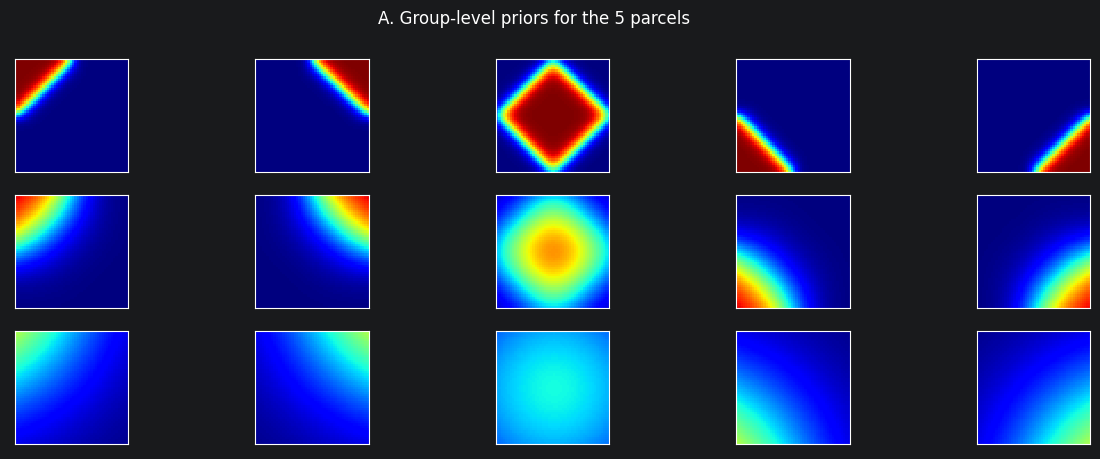

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
grid.plot_maps(pt.vstack(prior), cmap='jet', vmax=1, grid=[3, 5])
plt.suptitle('A. Group-level priors for the 5 parcels')
plt.show()


### Supplementary Figure 1, Panel C

Example individual parcellations from the same parameter sweep.

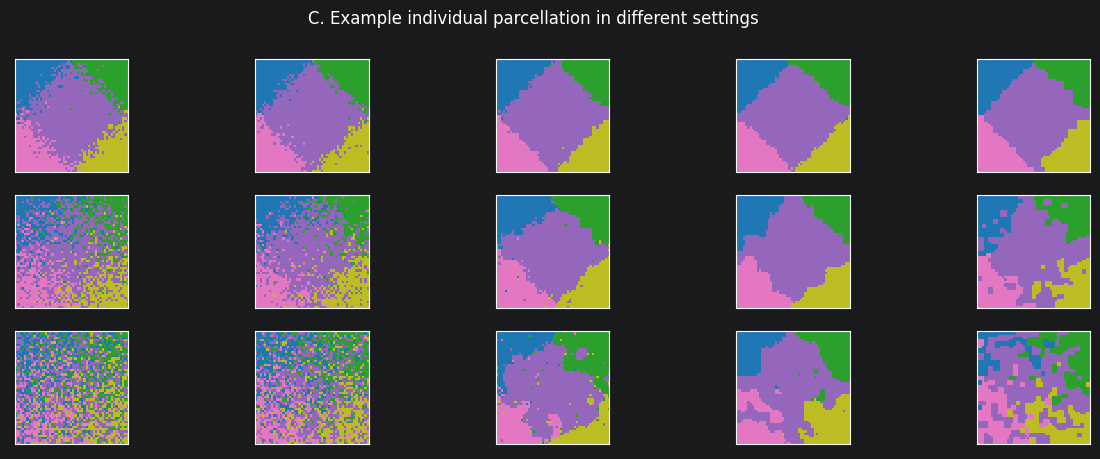

In [11]:
plt.figure(figsize=(15, 5))
grid.plot_maps(pt.stack(samples), cmap='tab10', vmax=5, grid=[3, 5])
plt.suptitle('C. Example individual parcellation in different settings')
plt.show()


### Supplementary Figure 1, Panels B and D

This cell reproduces the burn-in visualization from `make_cmpRBM_data(..., do_plot=1)` and then shows the example set of 10 individual maps used for panel **D**.

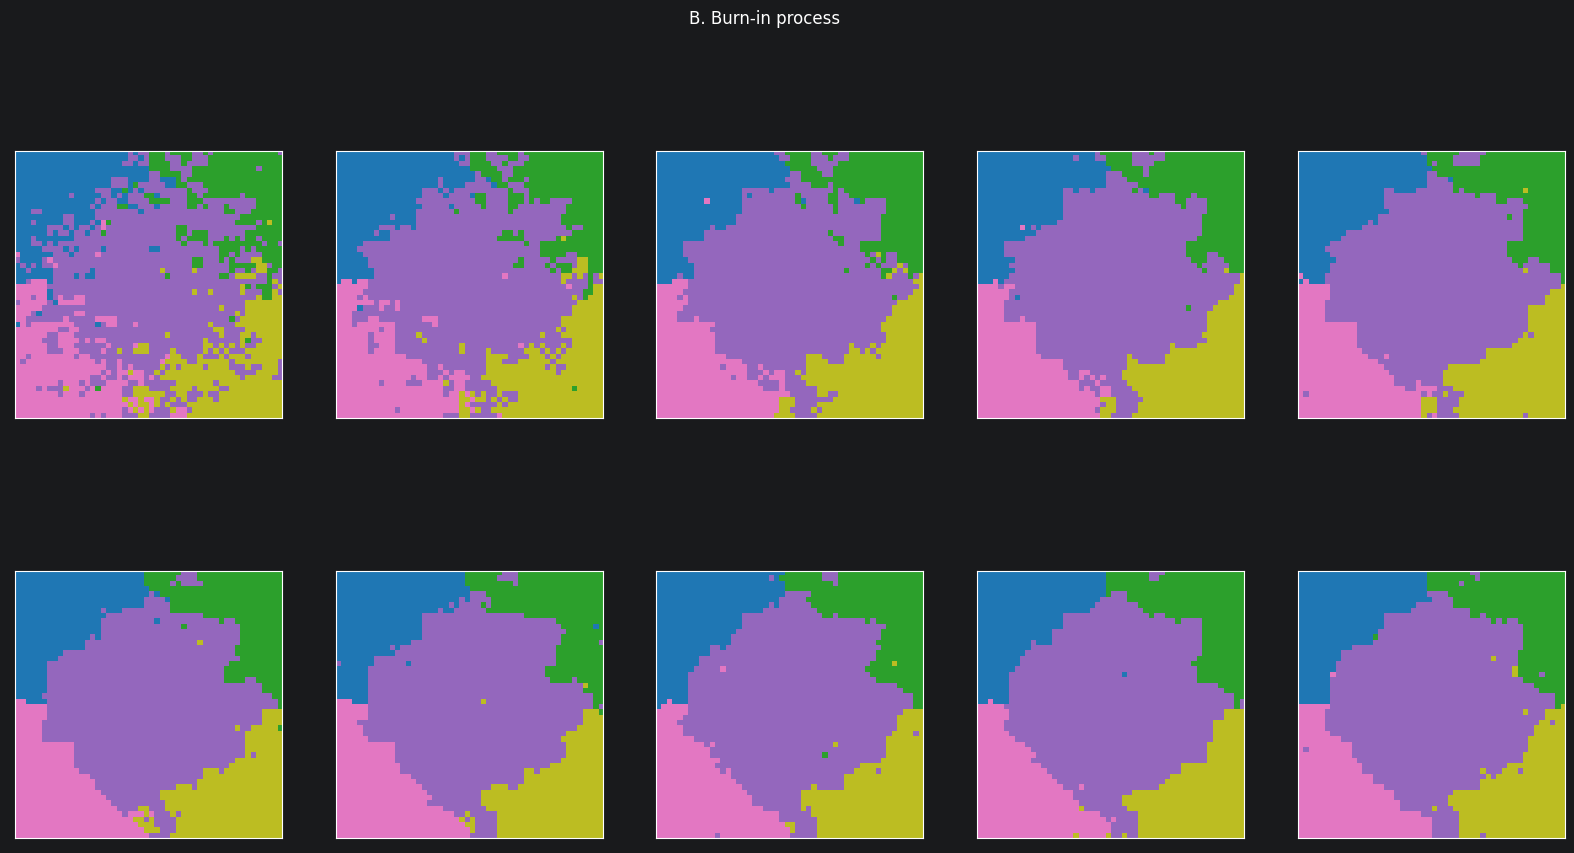

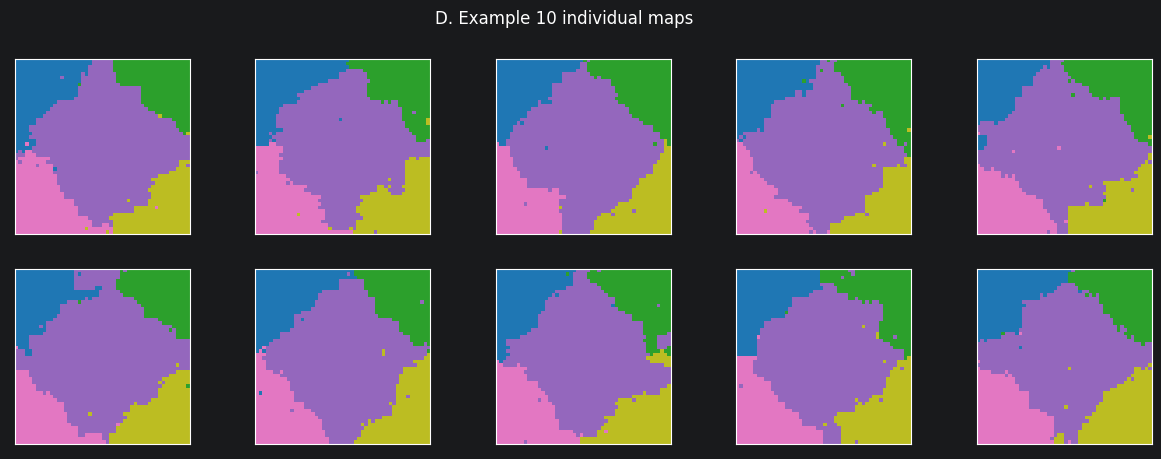

In [12]:
num_subj = 10
_, _, Utrue, MT, grid = sim.make_cmpRBM_data(
    50,
    5,
    N=num_subj,
    num_subj=10,
    theta_mu=240,
    theta_w=1.2,
    emission_model=None,
    do_plot=1,
)

U_ind = sim.ar.sample_multinomial(MT.arrange.marginal_prob(), shape=(num_subj, 5, grid.P))

plt.figure(figsize=(15, 5))
grid.plot_maps(Utrue, cmap='tab10', vmax=5, grid=[2, 5])
plt.suptitle('D. Example 10 individual maps')
plt.show()


## Supplementary Figure 2

The next cell runs the simulation block used for Supplementary Figure 2.

For interactive use, keep `num_sim=1` for 1 simulation. The results reported in the paper has 100 times simulation. The evaluation plot cell below can also reuse a cached TSV file if one already exists.

In [ ]:
num_sim = 1
theta_mu = 240

grid, DD, records, rbm, models, Utrue, emloglik_train, GM, IM = sim.simulation(
    theta_mu=theta_mu,
    num_sim=num_sim,
)

print(DD.shape)
DD.head()


### Supplementary Figure 2, Panel A

Posterior / probability visualization for the fitted models on one example subject.

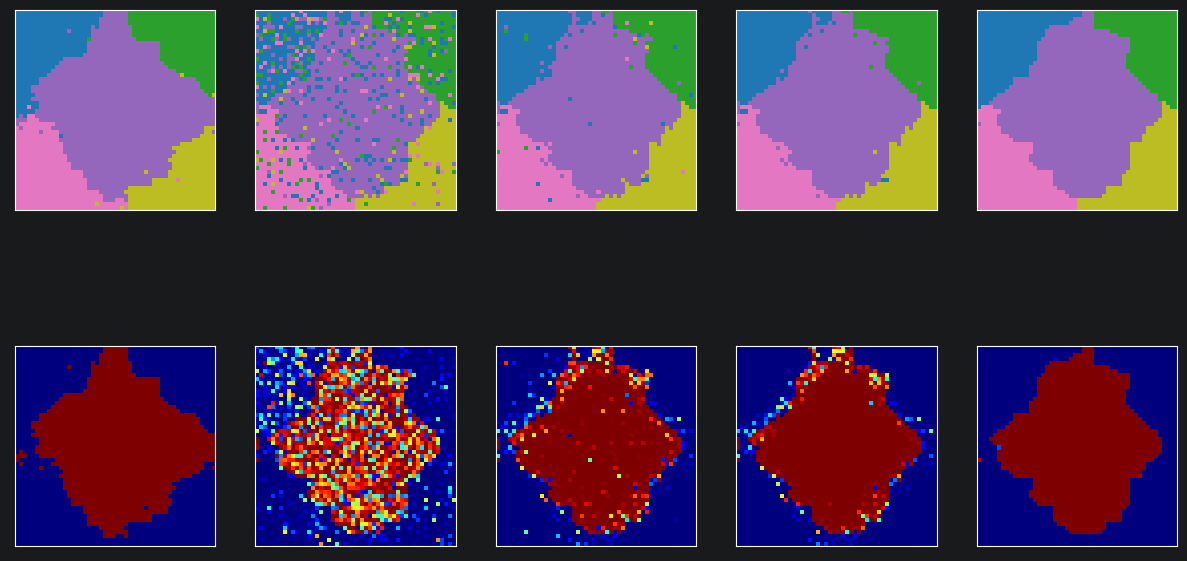

In [13]:
sim.plot_individual_Uhat(models[:-1], Utrue[0:1], emloglik_train[0:1], grid, style='mixed')


### Supplementary Figure 2, Panels B/C/D

Use a cached TSV if available; otherwise use the `DD` table from the current run. Uncomment the save line if you want to keep the current run as the cached evaluation table.

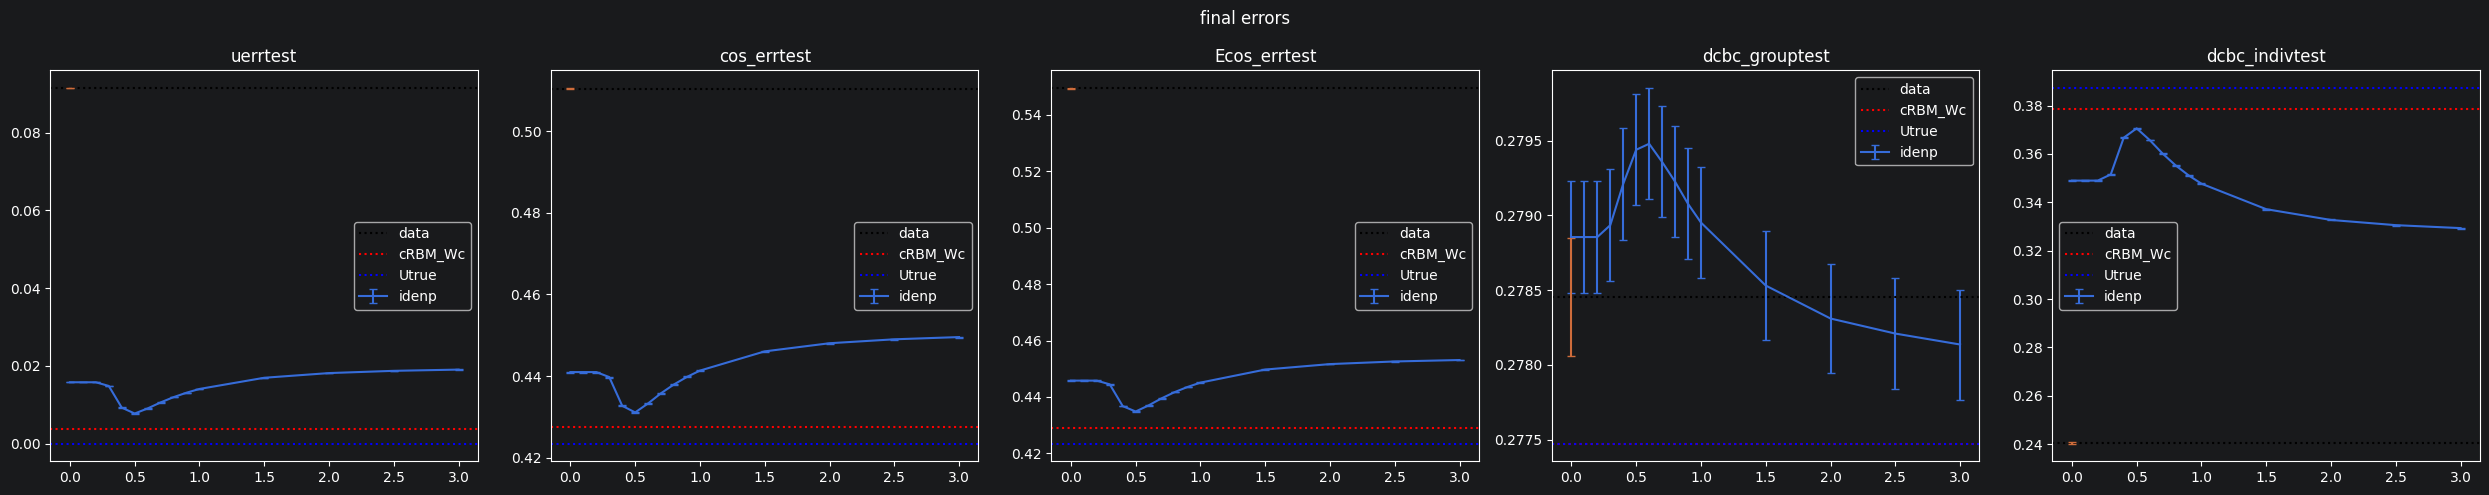

In [2]:
output_file = sim.RESULT_DIR / 'eval_cpmRBM_fit.tsv'

if output_file.exists():
    DD_plot = pd.read_csv(output_file, delimiter='	')
else:
    DD_plot = DD.copy()
    # DD_plot.to_csv(output_file, index=False, sep='	')

sim.plot_evaluation(DD_plot, types=['test'])


## Notes

- The notebook intentionally mirrors the `__main__` function of `simulation.py`.
- If you change the script later, update the corresponding notebook cells instead of relying on the old outputs.
- For a full reproduction run in the paper, you can increase `num_sim` in the Supplementary Figure 2 section and optionally save the resulting `DD` table to `results/1.simulation/eval_cpmRBM_fit.tsv`.